In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("supply_chain_data.csv")

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df.head()

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,4893,4.766231,6.053952,3.840976,28701,16975,2778,228,26,83
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,4453,4.304335,3.886996,2.113929,36198,14052,1535,288,16,39
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,5956,1.030779,7.335160,4.211437,22784,9863,13435,153,3,49
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,5814,2.871244,1.393481,1.751671,13172,15911,14508,143,39,35
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,2279,4.060930,4.212666,4.231919,39619,19011,1904,296,30,67


In [5]:
df.columns

Index(['Warehouse_ID', 'Location', 'Current_Stock', 'Demand_Forecast',
       'Lead_Time_Days', 'Shipping_Time_Days', 'Stockout_Risk',
       'Operational_Cost', 'Supplier_ID', 'Product_Category', 'Monthly_Sales',
       'Order_Processing_Time', 'Return_Rate', 'Customer_Rating',
       'Warehouse_Capacity', 'Storage_Cost', 'Transportation_Cost',
       'Backorder_Quantity', 'Damaged_Goods', 'Employee_Count'],
      dtype='object')

In [6]:
df.shape

(500, 20)

In [7]:
df.isnull().sum()

Warehouse_ID             0
Location                 0
Current_Stock            0
Demand_Forecast          0
Lead_Time_Days           0
Shipping_Time_Days       0
Stockout_Risk            0
Operational_Cost         0
Supplier_ID              0
Product_Category         0
Monthly_Sales            0
Order_Processing_Time    0
Return_Rate              0
Customer_Rating          0
Warehouse_Capacity       0
Storage_Cost             0
Transportation_Cost      0
Backorder_Quantity       0
Damaged_Goods            0
Employee_Count           0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Warehouse_ID           500 non-null    object 
 1   Location               500 non-null    object 
 2   Current_Stock          500 non-null    int64  
 3   Demand_Forecast        500 non-null    int64  
 4   Lead_Time_Days         500 non-null    int64  
 5   Shipping_Time_Days     500 non-null    int64  
 6   Stockout_Risk          500 non-null    int64  
 7   Operational_Cost       500 non-null    int64  
 8   Supplier_ID            500 non-null    object 
 9   Product_Category       500 non-null    object 
 10  Monthly_Sales          500 non-null    int64  
 11  Order_Processing_Time  500 non-null    float64
 12  Return_Rate            500 non-null    float64
 13  Customer_Rating        500 non-null    float64
 14  Warehouse_Capacity     500 non-null    int64  
 15  Storag

In [10]:
df.describe()

,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,2722.822000,2957.050000,5.958000,3.948000,14.944000,65886.354000,5335.572000,2.750462,5.229366,3.090865,30032.818000,10263.83400,8001.086000,147.380000,24.684000,52.810000
std,1314.878786,1398.763988,2.630223,1.921635,5.923431,20283.576821,2619.353688,1.262967,2.661448,1.156971,11921.277948,5584.14567,4269.354045,87.880656,14.868298,27.888087
min,519.000000,402.000000,2.000000,1.000000,5.000000,30165.000000,1004.000000,0.505159,0.506755,1.004825,10338.000000,1083.00000,515.000000,0.000000,0.000000,5.000000
25%,1565.250000,1745.750000,4.000000,2.000000,10.000000,48731.750000,2978.000000,1.644623,3.085484,2.073853,19486.750000,5335.75000,4294.500000,71.750000,11.000000,28.000000
50%,2670.000000,3094.000000,6.000000,4.000000,15.000000,65733.500000,5234.000000,2.817771,5.128133,3.148014,29862.500000,10023.00000,7973.000000,141.000000,25.000000,53.000000
75%,3842.750000,4152.500000,8.000000,6.000000,20.000000,82900.250000,7550.750000,3.782273,7.406404,4.137274,40692.250000,15162.00000,11857.000000,224.000000,37.000000,78.000000
max,4998.000000,5200.000000,10.000000,7.000000,25.000000,99965.000000,9931.000000,4.954139,9.992465,4.998258,49979.000000,19979.00000,14988.000000,300.000000,50.000000,100.000000


## Eda analysis


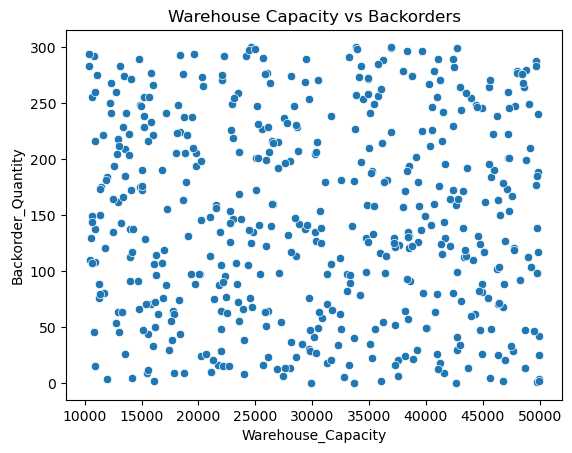

In [11]:
plt.figure()
sns.scatterplot(data=df, x='Warehouse_Capacity', y='Backorder_Quantity')
plt.title("Warehouse Capacity vs Backorders")
plt.show()

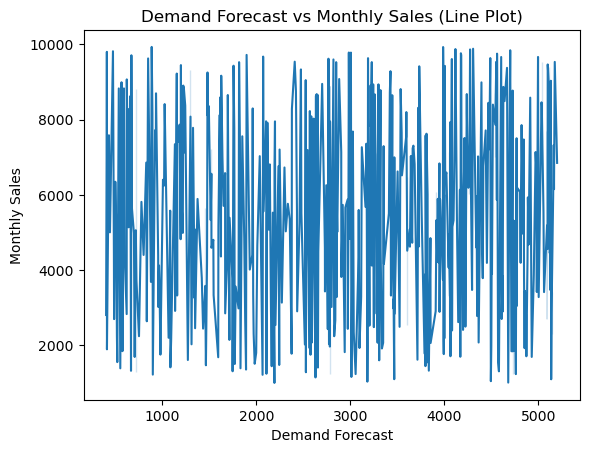

In [12]:
plt.figure()
sns.lineplot(data=df, x='Demand_Forecast', y='Monthly_Sales')
plt.title("Demand Forecast vs Monthly Sales (Line Plot)")
plt.xlabel("Demand Forecast")
plt.ylabel("Monthly Sales")
plt.show()

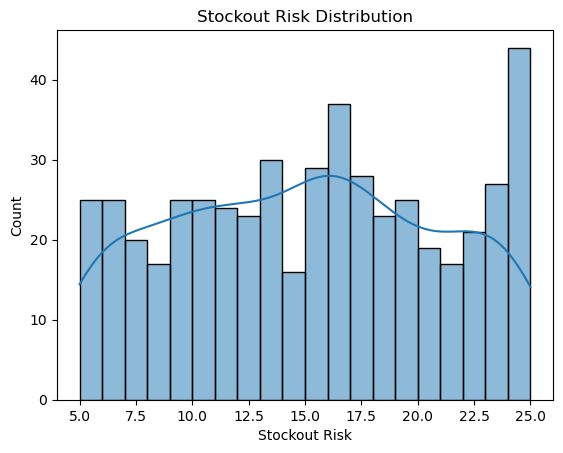

In [13]:
plt.figure()
sns.histplot(df['Stockout_Risk'], bins=20, kde=True)
plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout Risk")
plt.show()

# Feature Engineering

In [14]:
df['Inventory_gap'] = df['Current_Stock']- df['Demand_Forecast']

In [15]:
df['Inventory_status']= df['Inventory_gap'].apply(lambda x:'Shortage' if x<0 else 'Excess' if x>1000 else 'Balanced')

In [16]:
df.head()

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count,Inventory_gap,Inventory_status
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,4893,4.766231,6.053952,3.840976,28701,16975,2778,228,26,83,3442,Excess
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,4453,4.304335,3.886996,2.113929,36198,14052,1535,288,16,39,-2090,Shortage
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,5956,1.030779,7.335160,4.211437,22784,9863,13435,153,3,49,420,Balanced
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,5814,2.871244,1.393481,1.751671,13172,15911,14508,143,39,35,1442,Excess
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,2279,4.060930,4.212666,4.231919,39619,19011,1904,296,30,67,-3947,Shortage


In [17]:
df['Delivery_delay'] = df['Shipping_Time_Days'] - df['Lead_Time_Days']

In [18]:
df['Delivery_Status'] = df['Delivery_delay'].apply(lambda x: 'Delayed' if x>0 else 'On-Time')

In [19]:
df.head()

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count,Inventory_gap,Inventory_status,Delivery_delay,Delivery_Status
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,4893,4.766231,6.053952,3.840976,28701,16975,2778,228,26,83,3442,Excess,-5,On-Time
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,4453,4.304335,3.886996,2.113929,36198,14052,1535,288,16,39,-2090,Shortage,3,Delayed
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,5956,1.030779,7.335160,4.211437,22784,9863,13435,153,3,49,420,Balanced,0,On-Time
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,5814,2.871244,1.393481,1.751671,13172,15911,14508,143,39,35,1442,Excess,-1,On-Time
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,2279,4.060930,4.212666,4.231919,39619,19011,1904,296,30,67,-3947,Shortage,5,Delayed


In [20]:
df['Total_logistic_cost'] = df['Storage_Cost']+df['Transportation_Cost']

In [21]:
df["Stockout_Probability"] = df["Demand_Forecast"] / (df["Current_Stock"] + 1)

In [22]:
df['Cost_per_unit']= df['Total_logistic_cost']/df['Monthly_Sales']

# RESULTS

In [23]:
df.head()

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count,Inventory_gap,Inventory_status,Delivery_delay,Delivery_Status,Total_logistic_cost,Stockout_Probability,Cost_per_unit
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,4893,4.766231,6.053952,3.840976,28701,16975,2778,228,26,83,3442,Excess,-5,On-Time,19753,0.123249,4.036992
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,4453,4.304335,3.886996,2.113929,36198,14052,1535,288,16,39,-2090,Shortage,3,Delayed,15587,1.688757,3.500337
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,5956,1.030779,7.335160,4.211437,22784,9863,13435,153,3,49,420,Balanced,0,On-Time,23298,0.911629,3.911686
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,5814,2.871244,1.393481,1.751671,13172,15911,14508,143,39,35,1442,Excess,-1,On-Time,30419,0.350000,5.232026
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,2279,4.060930,4.212666,4.231919,39619,19011,1904,296,30,67,-3947,Shortage,5,Delayed,20915,5.871605,9.177271


In [24]:
df.to_csv("clean_supply_chain.csv",index = False)

In [25]:
df.shape

(500, 27)